# Global Annotation Comparison

Agreement metrics across all three annotation tasks:
- **Event Relation** — span event labels (binary) + temporal order (nominal: span1_first / simultaneous / too_hard_to_tell) + causality (nominal: direct_cause / enables / not_related)
- **Agency** — 5 Likert dimensions (1–5): focalization, emotion, cognition, change_of_state, conflict
- **Setting** — 4 Likert dimensions (1–5): concreteness, temporal_grounding, spatial_grounding, sensory

Metrics: exact match, within-1 (|diff| ≤ 1), MAE, Krippendorff's α, ICC(2,1).  
Nominal dimensions show only exact match and Krippendorff's α (nominal). Rows with fewer than 3 shared instances show `—`.

In [ ]:
import html
from itertools import combinations

import numpy as np
import pandas as pd
import krippendorff
from IPython.display import display, HTML

from nb_utils import load, DIMENSIONS, annotators_for


## Configuration

In [ ]:
# Task definitions. Dimensions come from nb_utils so they are declared once;
# annotators are discovered from the parquet columns in the next cell.
TASKS = {
    'event_relation': {
        'label':      'Event Relation',
        'format':     'event_relation',
        'dimensions': DIMENSIONS['event_relation'],
    },
    'agency': {
        'label':      'Agency',
        'format':     'likert',
        'dimensions': DIMENSIONS['agency'],
    },
    'setting': {
        'label':      'Setting',
        'format':     'likert',
        'dimensions': DIMENSIONS['setting'],
    },
}

MIN_PAIRS = 3   # minimum shared instances required to report agreement metrics


## Load Data

In [ ]:
# Everything is read from the exported parquets in ../data/. To refresh them
# after a new round of annotation, run export_annotations.py in potato/teagan_tasks.

corpus = load('corpus')
rows_in_order = corpus.to_dict('records')
dataset_order = [r['safe_instance_id'] for r in rows_in_order]
print(f'Dataset: {len(dataset_order)} instances')

all_data = {}   # task_key -> annotator -> {inst_id -> {dimension: value}}

for task_key, cfg in TASKS.items():
    df   = load(task_key)
    dims = cfg['dimensions']

    # Annotator handles present for this task, excluding the adjudicated 'gold'
    # copy (which duplicates whichever annotator was the adjudicator).
    cfg['annotators'] = [a for a in annotators_for(df, dims[0]) if a != 'gold']

    all_data[task_key] = {}
    for ann in cfg['annotators']:
        cols = {d: f'{d}_{ann}' for d in dims if f'{d}_{ann}' in df.columns}
        sub  = df[['safe_instance_id'] + list(cols.values())]
        sub  = sub.dropna(subset=list(cols.values()), how='all')

        records = {}
        for row in sub.to_dict('records'):
            entry = {}
            for dim, col in cols.items():
                val = row[col]
                if pd.isna(val):
                    continue
                entry[dim] = int(val) if cfg['format'] == 'likert' else val
            records[row['safe_instance_id']] = entry
        all_data[task_key][ann] = records
        print(f"  {cfg['label']} / {ann}: {len(records)} instances")


## Metric Helpers

In [10]:
def exact_match(pairs):
    if not pairs: return None
    return sum(a == b for a, b in pairs) / len(pairs)

def within_one(pairs):
    if not pairs: return None
    return sum(abs(a - b) <= 1 for a, b in pairs) / len(pairs)

def mae(pairs):
    if not pairs: return None
    return float(np.mean([abs(a - b) for a, b in pairs]))

def cohen_kappa(pairs):
    """Cohen's κ for nominal/binary data with 2 raters."""
    if len(pairs) < 2: return None
    n = len(pairs)
    y1, y2 = zip(*pairs)
    cats = sorted(set(y1) | set(y2), key=str)
    if len(cats) < 2: return None
    p_o = sum(a == b for a, b in pairs) / n
    p_e = sum((y1.count(c) / n) * (y2.count(c) / n) for c in cats)
    if p_e == 1: return None
    return (p_o - p_e) / (1 - p_e)

def alpha(pairs, binary=False):
    """Krippendorff's alpha. Nominal metric for binary/categorical, interval for ordinal."""
    if len(pairs) < 2: return None
    y1, y2 = zip(*pairs)
    all_vals = sorted(set(y1) | set(y2), key=str)
    if len(all_vals) < 2: return None
    if not all(isinstance(v, (int, float)) for v in all_vals):
        enc = {v: i for i, v in enumerate(all_vals)}
        y1 = [enc[v] for v in y1]
        y2 = [enc[v] for v in y2]
    level = 'nominal' if binary else 'interval'
    data = np.array([list(y1), list(y2)], dtype=float)
    try:
        return krippendorff.alpha(data, level_of_measurement=level)
    except Exception:
        return None

def icc_two_way(pairs):
    if len(pairs) < 2: return None
    data = np.array(pairs, dtype=float)
    n, k = data.shape
    grand_mean    = data.mean()
    subject_means = data.mean(axis=1)
    rater_means   = data.mean(axis=0)
    SS_subjects = k * ((subject_means - grand_mean) ** 2).sum()
    SS_raters   = n * ((rater_means   - grand_mean) ** 2).sum()
    SS_total    = ((data - grand_mean) ** 2).sum()
    SS_error    = SS_total - SS_subjects - SS_raters
    MS_subjects = SS_subjects / (n - 1)
    MS_raters   = SS_raters   / (k - 1)
    MS_error    = SS_error    / ((n - 1) * (k - 1))
    denom = MS_subjects + (k - 1) * MS_error + k * (MS_raters - MS_error) / n
    if denom == 0: return None
    return (MS_subjects - MS_error) / denom

def f1_score(pairs):
    """F1 with pair[0] as gold (tejo9855) and pair[1] as predicted (maria).
    Positive class = 1. Only meaningful for binary dimensions."""
    if not pairs: return None
    tp = sum(g == 1 and p == 1 for g, p in pairs)
    fp = sum(g == 0 and p == 1 for g, p in pairs)
    fn = sum(g == 1 and p == 0 for g, p in pairs)
    if (tp + fp) == 0 or (tp + fn) == 0: return None
    precision = tp / (tp + fp)
    recall    = tp / (tp + fn)
    if precision + recall == 0: return None
    return 2 * precision * recall / (precision + recall)

def fmt(v, pct=False):
    if v is None: return '<span style="color:#bbb">—</span>'
    return f'{v*100:.1f}%' if pct else f'{v:.3f}'

def compute_row(pairs, binary=False):
    n = len(pairs)
    if n < MIN_PAIRS:
        return {'n': n, 'em': None, 'w1': None, 'mae': None, 'kappa': None, 'alpha': None, 'icc': None, 'f1': None}
    return {
        'n':     n,
        'em':    exact_match(pairs),
        'w1':    None if binary else within_one(pairs),
        'mae':   None if binary else mae(pairs),
        'kappa': cohen_kappa(pairs) if binary else None,
        'alpha': alpha(pairs, binary=binary),
        'icc':   None if binary else icc_two_way(pairs),
        'f1':    f1_score(pairs) if binary else None,
    }

def collect_er_pairs(er1, er2):
    """Collect annotation value pairs for event relation from two annotators."""
    shared = set(er1) & set(er2)
    sp1_ev, sp2_ev, temp_pairs, temp_binary_pairs, caus_pairs, caus_binary_pairs = [], [], [], [], [], []
    for inst_id in dataset_order:
        if inst_id not in shared: continue
        a1, a2 = er1.get(inst_id), er2.get(inst_id)
        if a1 is None or a2 is None: continue
        sp1_ev.append((int(bool(a1.get('span1_is_event'))), int(bool(a2.get('span1_is_event')))))
        sp2_ev.append((int(bool(a1.get('span2_is_event'))), int(bool(a2.get('span2_is_event')))))
        if a1.get('span1_is_event') and a1.get('span2_is_event') and \
           a2.get('span1_is_event') and a2.get('span2_is_event'):
            t1, t2 = a1.get('temporal_order'), a2.get('temporal_order')
            c1, c2 = a1.get('causality_rating'), a2.get('causality_rating')
            if t1 is not None and t2 is not None:
                temp_pairs.append((t1, t2))
                temp_binary_pairs.append((
                    int(t1 in ('span1_first', 'span2_first')),
                    int(t2 in ('span1_first', 'span2_first')),
                ))
            # Exclude simultaneous from causality: causal direction is undefined
            # when either annotator judged the events as simultaneous.
            if c1 is not None and c2 is not None and \
               t1 != 'simultaneous' and t2 != 'simultaneous':
                caus_pairs.append((c1, c2))
                caus_binary_pairs.append((
                    int(c1 != 'not_related'),
                    int(c2 != 'not_related'),
                ))
    return sp1_ev, sp2_ev, temp_pairs, temp_binary_pairs, caus_pairs, caus_binary_pairs

## Global Agreement Summary

One row per annotated dimension. Rows with fewer than 3 shared instances show `—`.

In [11]:
table_rows = []

# ── Event Relation ────────────────────────────────────────────────────────────
er_anns = [a for a in TASKS['event_relation']['annotators'] if all_data['event_relation'].get(a)]
for ann1, ann2 in combinations(er_anns, 2):
    sp1_ev, sp2_ev, temp_pairs, temp_binary_pairs, caus_pairs, caus_binary_pairs = collect_er_pairs(
        all_data['event_relation'][ann1], all_data['event_relation'][ann2])
    ann_pair = f'{ann1} / {ann2}'
    for label, pairs, binary in [
        ('Span is event',                    sp1_ev + sp2_ev,    True),
        ('Temporal order (nominal)',         temp_pairs,         True),
        ('Temporal order (directional / not)', temp_binary_pairs, True),
        ('Causality (nominal)',              caus_pairs,         True),
        ('Causality (causal / not)',         caus_binary_pairs,  True),
    ]:
        row = compute_row(pairs, binary=binary)
        row['task'] = 'Event Relation'; row['dim'] = label; row['ann_pair'] = ann_pair
        table_rows.append(row)

# ── Agency ────────────────────────────────────────────────────────────────────
ag_anns = [a for a in TASKS['agency']['annotators'] if all_data['agency'].get(a)]
for ann1, ann2 in combinations(ag_anns, 2):
    shared = set(all_data['agency'][ann1]) & set(all_data['agency'][ann2])
    ann_pair = f'{ann1} / {ann2}'
    for dim in TASKS['agency']['dimensions']:
        val_pairs = []
        for inst_id in dataset_order:
            if inst_id not in shared: continue
            v1 = all_data['agency'][ann1].get(inst_id, {}).get(dim)
            v2 = all_data['agency'][ann2].get(inst_id, {}).get(dim)
            if v1 is not None and v2 is not None:
                val_pairs.append((v1, v2))
        row = compute_row(val_pairs)
        row['task'] = 'Agency'
        row['dim']  = dim.replace('agency_', '').replace('_', ' ').title()
        row['ann_pair'] = ann_pair
        table_rows.append(row)

# ── Setting (pairwise) ────────────────────────────────────────────────────────
st_anns = [a for a in TASKS['setting']['annotators'] if all_data['setting'].get(a)]
for ann1, ann2 in combinations(st_anns, 2):
    shared = set(all_data['setting'][ann1]) & set(all_data['setting'][ann2])
    ann_pair = f'{ann1} / {ann2}'
    for dim in TASKS['setting']['dimensions']:
        val_pairs = []
        for inst_id in dataset_order:
            if inst_id not in shared: continue
            v1 = all_data['setting'][ann1].get(inst_id, {}).get(dim)
            v2 = all_data['setting'][ann2].get(inst_id, {}).get(dim)
            if v1 is not None and v2 is not None:
                val_pairs.append((v1, v2))
        row = compute_row(val_pairs)
        row['task'] = 'Setting'
        row['dim']  = dim.replace('setting_', '').replace('_', ' ').title()
        row['ann_pair'] = ann_pair
        table_rows.append(row)

# ── Setting pooled: tejo9855 vs roda9210+maria (disjoint sets → clean pool) ──
_tejo  = all_data['setting'].get('tejo9855', {})
_roda  = all_data['setting'].get('roda9210', {})
_maria = all_data['setting'].get('maria', {})
if _tejo and (_roda or _maria):
    ann_pair = 'tejo9855 / roda9210+maria'
    for dim in TASKS['setting']['dimensions']:
        val_pairs = []
        for inst_id in dataset_order:
            v1 = (_tejo.get(inst_id) or {}).get(dim)
            v2 = (_roda.get(inst_id) or {}).get(dim)
            if v1 is not None and v2 is not None:
                val_pairs.append((v1, v2))
        for inst_id in dataset_order:
            v1 = (_tejo.get(inst_id) or {}).get(dim)
            v2 = (_maria.get(inst_id) or {}).get(dim)
            if v1 is not None and v2 is not None:
                val_pairs.append((v1, v2))
        row = compute_row(val_pairs)
        row['task'] = 'Setting'
        row['dim']  = dim.replace('setting_', '').replace('_', ' ').title()
        row['ann_pair'] = ann_pair
        table_rows.append(row)

# ── Render ────────────────────────────────────────────────────────────────────
TASK_COLORS = {
    'Event Relation': '#e8f4fd',
    'Agency':         '#fdf3e8',
    'Setting':        '#edf8ee',
}

header = (
    '<tr style="background:#f0f0f0">'
    '<th style="padding:6px 12px;text-align:left">Task</th>'
    '<th style="padding:6px 12px;text-align:left">Dimension</th>'
    '<th style="padding:6px 12px">N</th>'
    '<th style="padding:6px 12px">Exact match</th>'
    '<th style="padding:6px 12px">Within 1</th>'
    '<th style="padding:6px 12px">MAE</th>'
    '<th style="padding:6px 12px">Krippendorff\'s α</th>'
    '<th style="padding:6px 12px">Cohen\'s κ</th>'
    '<th style="padding:6px 12px">ICC(2,1)</th>'
    '<th style="padding:6px 12px">F1 (gold=tejo9855)</th>'
    '<th style="padding:6px 12px;text-align:left;font-size:0.82em">Annotators</th>'
    '</tr>'
)

rows_html = ''
prev_task = None
prev_pair = None
for row in table_rows:
    bg = TASK_COLORS.get(row['task'], '#fff')
    if row['ann_pair'] != prev_pair:
        rows_html += (
            f'<tr style="background:#f8f8f8;border-top:2px solid #ccc">'
            f'<td colspan="11" style="padding:3px 12px;font-size:0.8em;color:#555;font-style:italic">'
            f'↳ {row["ann_pair"]}</td></tr>'
        )
    prev_pair = row['ann_pair']
    if row['task'] != prev_task:
        task_cell = f'<td style="padding:6px 12px;background:{bg};font-weight:bold">{row["task"]}</td>'
    else:
        task_cell = f'<td style="padding:6px 12px;background:{bg}"></td>'
    prev_task = row['task']
    rows_html += (
        f'<tr style="border-top:1px solid #eee">'
        f'{task_cell}'
        f'<td style="padding:6px 12px">{row["dim"]}</td>'
        f'<td style="padding:6px 12px;text-align:center">{row["n"]}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["em"], pct=True)}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["w1"], pct=True)}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["mae"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["alpha"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["kappa"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["icc"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{fmt(row["f1"])}</td>'
        f'<td style="padding:6px 12px;font-size:0.82em;color:#666">{row["ann_pair"]}</td>'
        f'</tr>'
    )

notes = (
    '<p style="color:#777;font-size:0.8em;margin-top:10px;line-height:1.6">'
    '<b>Within 1</b>: fraction of pairs differing by at most 1 point (ordinal only).<br>'
    '<b>MAE</b>: mean absolute error (ordinal only).<br>'
    '<b>Krippendorff\'s α</b>: nominal metric for binary/categorical labels; interval metric for ordinal scales.<br>'
    '<b>Cohen\'s κ</b>: chance-corrected agreement for nominal/binary labels (nominal dims only).<br>'
    '<b>ICC(2,1)</b>: two-way random effects; credits agreement even when one annotator rates systematically higher/lower (ordinal only).<br>'
    '<b>F1</b>: binary dims only; tejo9855 = gold, maria = predicted, positive class = 1.<br>'
    '<b>roda9210+maria</b>: pooled comparison across 99 instances; sets are fully disjoint so no instance is double-counted.<br>'
    f'Rows with N &lt; {MIN_PAIRS} show — (insufficient shared instances).'
    '</p>'
)

display(HTML(
    '<div style="font-family:sans-serif">'
    '<table style="border-collapse:collapse;font-size:0.92em">'
    f'<thead>{header}</thead><tbody>{rows_html}</tbody>'
    '</table>'
    + notes +
    '</div>'
))

In [12]:
from collections import defaultdict

def _mean(vals):
    vals = [v for v in vals if v is not None]
    return sum(vals) / len(vals) if vals else None

groups = defaultdict(list)
for row in table_rows:
    groups[(row['task'], row['ann_pair'])].append(row)

summary_rows = []
for (task, ann_pair), rows in groups.items():
    if task in ('Setting', 'Agency'):
        summary_rows.append({
            'Task':      task,
            'Annotators': ann_pair,
            'Avg α':     _mean([r['alpha'] for r in rows]),
            'Avg MAE':   _mean([r['mae']   for r in rows]),
            'Avg κ':     None,
            'Avg F1':    None,
        })
    else:
        summary_rows.append({
            'Task':      task,
            'Annotators': ann_pair,
            'Avg α':     None,
            'Avg MAE':   None,
            'Avg κ':     _mean([r['kappa'] for r in rows]),
            'Avg F1':    _mean([r['f1']    for r in rows]),
        })

TASK_COLORS = {'Event Relation': '#e8f4fd', 'Agency': '#fdf3e8', 'Setting': '#edf8ee'}

hdr = (
    '<tr style="background:#f0f0f0">'
    '<th style="padding:6px 14px;text-align:left">Task</th>'
    '<th style="padding:6px 14px;text-align:left">Annotators</th>'
    '<th style="padding:6px 14px">Avg Krippendorff\'s α</th>'
    '<th style="padding:6px 14px">Avg MAE</th>'
    '<th style="padding:6px 14px">Avg Cohen\'s κ</th>'
    '<th style="padding:6px 14px">Avg F1</th>'
    '</tr>'
)

body = ''
prev_task = None
for r in summary_rows:
    bg = TASK_COLORS.get(r['Task'], '#fff')
    task_cell = (
        f'<td style="padding:6px 14px;background:{bg};font-weight:bold">{r["Task"]}</td>'
        if r['Task'] != prev_task else
        f'<td style="padding:6px 14px;background:{bg}"></td>'
    )
    prev_task = r['Task']
    def _fmt(v):
        return fmt(v) if v is not None else '<span style="color:#bbb">—</span>'
    body += (
        f'<tr style="border-top:1px solid #eee">'
        f'{task_cell}'
        f'<td style="padding:6px 14px;font-size:0.85em;color:#555">{r["Annotators"]}</td>'
        f'<td style="padding:6px 14px;text-align:center">{_fmt(r["Avg α"])}</td>'
        f'<td style="padding:6px 14px;text-align:center">{_fmt(r["Avg MAE"])}</td>'
        f'<td style="padding:6px 14px;text-align:center">{_fmt(r["Avg κ"])}</td>'
        f'<td style="padding:6px 14px;text-align:center">{_fmt(r["Avg F1"])}</td>'
        f'</tr>'
    )

display(HTML(
    '<div style="font-family:sans-serif;margin-top:16px">'
    '<b style="font-size:1.05em">Per-task average metrics</b>'
    '<table style="border-collapse:collapse;font-size:0.92em;margin-top:8px">'
    f'<thead>{hdr}</thead><tbody>{body}</tbody>'
    '</table>'
    '<p style="color:#777;font-size:0.8em;margin-top:6px">'
    'Averages across all dimensions per task / annotator pair. '
    'Setting &amp; Agency: α (interval) and MAE. '
    'Event Relation: κ (nominal) and F1 (positive class = 1, gold = tejo9855).'
    '</p></div>'
))

Task,Annotators,Avg Krippendorff's α,Avg MAE,Avg Cohen's κ,Avg F1
Event Relation,tejo9855 / maria,—,—,0.676,0.906
,tejo9855 / akritidhasmana,—,—,0.454,0.828
,maria / akritidhasmana,—,—,0.265,0.734
Agency,tejo9855 / maria,0.756,0.620,—,—
Setting,tejo9855 / roda9210,0.643,0.529,—,—
,tejo9855 / maria,0.717,0.612,—,—
,tejo9855 / akritidhasmana,0.604,0.524,—,—
,roda9210 / maria,—,—,—,—
,roda9210 / akritidhasmana,0.450,0.713,—,—
,maria / akritidhasmana,—,—,—,—


## Per-Task Agreement

Run any cell below independently to see metrics for just that task.

In [ ]:
def show_agreement(task_key):
    cfg = TASKS[task_key]
    TASK_COLORS = {'Event Relation': '#e8f4fd', 'Agency': '#fdf3e8', 'Setting': '#edf8ee'}
    bg = TASK_COLORS.get(cfg['label'], '#fff')
    table_rows = []

    anns = [a for a in cfg['annotators'] if all_data[task_key].get(a)]
    ann_pairs = list(combinations(anns, 2))

    if not ann_pairs:
        display(HTML(f'<p style="color:#888">Need ≥ 2 annotators with data for {cfg["label"]}.</p>'))
        return

    if cfg['format'] == 'event_relation':
        for ann1, ann2 in ann_pairs:
            sp1_ev, sp2_ev, temp_pairs, temp_binary_pairs, caus_pairs, caus_binary_pairs = collect_er_pairs(
                all_data[task_key][ann1], all_data[task_key][ann2])
            ann_pair = f'{ann1} / {ann2}'
            for label, p, binary in [
                ('Span is event',                      sp1_ev + sp2_ev,    True),
                ('Temporal order (nominal)',           temp_pairs,         True),
                ('Temporal order (directional / not)', temp_binary_pairs,  True),
                ('Causality (nominal)',                caus_pairs,         True),
                ('Causality (causal / not)',           caus_binary_pairs,  True),
            ]:
                row = compute_row(p, binary=binary)
                row['task'] = cfg['label']; row['dim'] = label; row['ann_pair'] = ann_pair
                table_rows.append(row)

    else:  # likert
        prefix = task_key + '_'
        for ann1, ann2 in ann_pairs:
            shared = set(all_data[task_key][ann1]) & set(all_data[task_key][ann2])
            ann_pair = f'{ann1} / {ann2}'
            for dim in cfg['dimensions']:
                val_pairs = []
                for inst_id in dataset_order:
                    if inst_id not in shared: continue
                    v1 = all_data[task_key][ann1].get(inst_id, {}).get(dim)
                    v2 = all_data[task_key][ann2].get(inst_id, {}).get(dim)
                    if v1 is not None and v2 is not None:
                        val_pairs.append((v1, v2))
                row = compute_row(val_pairs)
                row['task'] = cfg['label']
                row['dim']  = dim.replace(prefix, '').replace('_', ' ').title()
                row['ann_pair'] = ann_pair
                table_rows.append(row)

        # pooled row for setting: tejo9855 vs roda9210+maria
        if task_key == 'setting':
            _tejo  = all_data['setting'].get('tejo9855', {})
            _roda  = all_data['setting'].get('roda9210', {})
            _maria = all_data['setting'].get('maria', {})
            if _tejo and (_roda or _maria):
                ann_pair = 'tejo9855 / roda9210+maria'
                for dim in cfg['dimensions']:
                    val_pairs = []
                    for inst_id in dataset_order:
                        v1 = (_tejo.get(inst_id) or {}).get(dim)
                        v2 = (_roda.get(inst_id) or {}).get(dim)
                        if v1 is not None and v2 is not None:
                            val_pairs.append((v1, v2))
                    for inst_id in dataset_order:
                        v1 = (_tejo.get(inst_id) or {}).get(dim)
                        v2 = (_maria.get(inst_id) or {}).get(dim)
                        if v1 is not None and v2 is not None:
                            val_pairs.append((v1, v2))
                    row = compute_row(val_pairs)
                    row['task'] = cfg['label']
                    row['dim']  = dim.replace(prefix, '').replace('_', ' ').title()
                    row['ann_pair'] = ann_pair
                    table_rows.append(row)

    header = (
        '<tr style="background:#f0f0f0">'
        '<th style="padding:6px 12px;text-align:left">Dimension</th>'
        '<th style="padding:6px 12px">N</th>'
        '<th style="padding:6px 12px">Exact match</th>'
        '<th style="padding:6px 12px">Within 1</th>'
        '<th style="padding:6px 12px">MAE</th>'
        '<th style="padding:6px 12px">Krippendorff\'s α</th>'
        '<th style="padding:6px 12px">Cohen\'s κ</th>'
        '<th style="padding:6px 12px">ICC(2,1)</th>'
        '<th style="padding:6px 12px">F1 (gold=tejo9855)</th>'
        '<th style="padding:6px 12px;text-align:left;font-size:0.82em">Annotators</th>'
        '</tr>'
    )

    rows_html = ''
    prev_pair = None
    for r in table_rows:
        if r['ann_pair'] != prev_pair:
            rows_html += (
                f'<tr style="background:#f0f0f0;border-top:2px solid #ccc">'
                f'<td colspan="10" style="padding:3px 12px;font-size:0.8em;color:#555;font-style:italic">'
                f'↳ {r["ann_pair"]}</td></tr>'
            )
        prev_pair = r['ann_pair']
        rows_html += (
            f'<tr style="border-top:1px solid #eee;background:{bg}">'
            f'<td style="padding:6px 12px">{r["dim"]}</td>'
            f'<td style="padding:6px 12px;text-align:center">{r["n"]}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["em"], pct=True)}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["w1"], pct=True)}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["mae"])}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["alpha"])}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["kappa"])}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["icc"])}</td>'
            f'<td style="padding:6px 12px;text-align:center">{fmt(r["f1"])}</td>'
            f'<td style="padding:6px 12px;font-size:0.82em;color:#666">{r["ann_pair"]}</td>'
            f'</tr>'
        )

    display(HTML(
        f'<div style="font-family:sans-serif">'
        f'<b style="font-size:1.05em">{cfg["label"]} Agreement</b>'
        f'<table style="border-collapse:collapse;font-size:0.92em;margin-top:8px">'
        f'<thead>{header}</thead><tbody>{rows_html}</tbody>'
        '</table></div>'
    ))

In [68]:
show_agreement('setting')

In [69]:
show_agreement('agency')

In [32]:
show_agreement('event_relation')

## Disagreement Examples

Each card shows the text snippet, a summary (when available), and a color-coded rating table.  
Sorted worst-first by max |diff|. Adjust `min_diff` or `max_show` as needed.

In [33]:
def show_disagreements(task_key, min_diff=1, max_show=50, ann1=None, ann2=None, feature=None):
    """Display instances where annotators disagree by >= min_diff, worst-first.

    ann1, ann2: optional annotator usernames to restrict to a single pair.
    feature:    optional dimension to filter on. Only instances where that
                specific feature disagrees are shown, sorted by its disagreement.
                - Likert tasks: use the dimension name or its short form, e.g.
                  'concreteness', 'setting_concreteness', 'focalization'.
                - Event relation: use 'span1_is_event', 'span2_is_event',
                  'temporal_order', or 'causality_rating'.
                If None, all dimensions are used (original behaviour).
    """
    cfg = TASKS[task_key]
    text_lookup = {r['safe_instance_id']: r for r in rows_in_order}
    DIFF_BG = ['#d4edda', '#fff3cd', '#fde8d8', '#f8d7da', '#f5c6cb']
    cell_bg = lambda d: '#f5f5f5' if d is None else DIFF_BG[min(d, len(DIFF_BG) - 1)]

    SPAN1_STYLE = 'background:#4e9af1;font-weight:600;border-radius:3px;padding:1px 4px;color:#fff'
    SPAN2_STYLE = 'background:#f4a432;font-weight:600;border-radius:3px;padding:1px 4px;color:#fff'
    CONTEXT = 150  # chars of context to show around the spans

    anns = [a for a in cfg['annotators'] if all_data[task_key].get(a)]
    ann_pairs = list(combinations(anns, 2))

    if ann1 is not None and ann2 is not None:
        target = tuple(sorted([ann1, ann2]))
        ann_pairs = [p for p in ann_pairs if tuple(sorted(p)) == target]
        if not ann_pairs:
            display(HTML(
                f'<p style="color:#c00">Pair ({ann1}, {ann2}) not found in {cfg["label"]}. '
                f'Available annotators with data: {anns}</p>'
            ))
            return

    if not ann_pairs:
        display(HTML(f'<p style="color:#888">Need ≥ 2 annotators with data for {cfg["label"]}.</p>'))
        return

    # Resolve feature name to canonical form
    feature_dim = None   # full dimension name for likert
    feature_er  = None   # field key for event_relation
    if feature is not None:
        if cfg['format'] == 'likert':
            prefix = task_key + '_'
            for dim in cfg['dimensions']:
                short = dim.replace(prefix, '')
                if feature.lower() in (dim.lower(), short.lower()):
                    feature_dim = dim
                    break
            if feature_dim is None:
                shorts = [d.replace(prefix, '') for d in cfg['dimensions']]
                display(HTML(
                    f'<p style="color:#c00">Feature "{feature}" not found in {cfg["label"]}. '
                    f'Available: {shorts}</p>'
                ))
                return
        elif cfg['format'] == 'event_relation':
            er_fields = ['span1_is_event', 'span2_is_event', 'temporal_order', 'causality_rating']
            if feature.lower() in [f.lower() for f in er_fields]:
                feature_er = next(f for f in er_fields if f.lower() == feature.lower())
            else:
                display(HTML(
                    f'<p style="color:#c00">Feature "{feature}" not found. '
                    f'Available: {er_fields}</p>'
                ))
                return

    def parse_span(raw):
        if not raw: return None
        try:
            parsed = json.loads(raw)
            return int(parsed[0]), int(parsed[1])
        except Exception:
            return None

    def highlighted_snippet(text, row):
        sp1 = parse_span(row.get('assigned_span1', ''))
        sp2 = parse_span(row.get('assigned_span2', ''))
        spans = []
        if sp1: spans.append((sp1[0], sp1[1], SPAN1_STYLE))
        if sp2: spans.append((sp2[0], sp2[1], SPAN2_STYLE))

        if spans:
            win_start = max(0, min(s[0] for s in spans) - CONTEXT)
            win_end   = min(len(text), max(s[1] for s in spans) + CONTEXT)
        else:
            win_start, win_end = 0, min(len(text), 400)

        chunk = text[win_start:win_end]
        adj = [(s[0] - win_start, s[1] - win_start, s[2]) for s in spans]

        parts = []
        pos = 0
        for start, end, style in sorted(adj, key=lambda x: x[0]):
            start = max(pos, max(0, start))
            end   = min(len(chunk), end)
            if start >= end: continue
            parts.append(html.escape(chunk[pos:start]))
            parts.append(f'<span style="{style}">{html.escape(chunk[start:end])}</span>')
            pos = end
        parts.append(html.escape(chunk[pos:]))

        prefix = '<span style="color:#aaa">… </span>' if win_start > 0 else ''
        suffix = '<span style="color:#aaa"> …</span>' if win_end < len(text) else ''
        return prefix + ''.join(parts) + suffix

    def text_card(inst_id):
        row = text_lookup.get(inst_id, {})
        text = row.get('sampled_text', '')
        snippet_html = highlighted_snippet(text, row)
        return (
            '<div style="padding:14px 16px;font-size:0.93em;color:#e0e0e0;'
            'line-height:1.85;border-bottom:1px solid #eee;word-spacing:0.02em">'
            + snippet_html +
            '</div>'
        )

    def dim_table(a1, a2, all_anns, data_rows):
        diff_label = f'|diff| ({a1} vs {a2})'
        hdr = '<tr style="background:#f0f0f0">'
        hdr += '<th style="padding:4px 10px;text-align:left">Dimension</th>'
        for ann in all_anns:
            hdr += f'<th style="padding:4px 10px">{ann}</th>'
        hdr += f'<th style="padding:4px 10px">{diff_label}</th></tr>'

        body = ''
        for label, vals, d in data_rows:
            body += f'<tr style="background:{cell_bg(d)};border-top:1px solid #eee">'
            body += f'<td style="padding:4px 10px">{label}</td>'
            for ann in all_anns:
                v = vals.get(ann)
                body += f'<td style="padding:4px 10px;text-align:center">{v if v is not None else "—"}</td>'
            body += f'<td style="padding:4px 10px;text-align:center">{d if d is not None else "—"}</td>'
            body += '</tr>'
        return f'<table style="border-collapse:collapse;font-size:0.88em">{hdr}{body}</table>'

    def instance_card(inst_id, sort_d, a1, a2, all_anns, data_rows):
        return (
            f'<div style="margin:14px 0;border:1px solid #ddd;border-radius:5px;overflow:hidden">'
            f'<div style="background:#f7f7f7;padding:5px 12px;font-size:0.78em;color:#888;'
            f'font-family:monospace">{inst_id} &nbsp;·&nbsp; max |diff| = {sort_d}</div>'
            + text_card(inst_id)
            + dim_table(a1, a2, all_anns, data_rows)
            + '</div>'
        )

    html_out = '<div style="font-family:sans-serif">'

    for a1, a2 in ann_pairs:
        records = []

        if cfg['format'] == 'likert':
            shared = set(all_data[task_key][a1]) & set(all_data[task_key][a2])
            dims = cfg['dimensions']
            prefix = task_key + '_'
            dim_labels = [d.replace(prefix, '').replace('_', ' ').title() for d in dims]
            for inst_id in dataset_order:
                if inst_id not in shared: continue
                v1d = all_data[task_key][a1].get(inst_id) or {}
                v2d = all_data[task_key][a2].get(inst_id) or {}
                r1 = [v1d.get(d) for d in dims]
                r2 = [v2d.get(d) for d in dims]
                diffs = [abs(x - y) if x is not None and y is not None else None for x, y in zip(r1, r2)]

                if feature_dim is not None:
                    fidx = dims.index(feature_dim)
                    sort_d = diffs[fidx]
                    if sort_d is None or sort_d < min_diff:
                        continue
                else:
                    sort_d = max((d for d in diffs if d is not None), default=0)
                    if sort_d < min_diff:
                        continue

                data_rows = []
                for i, label in enumerate(dim_labels):
                    vals = {}
                    for ann in anns:
                        vd = all_data[task_key][ann].get(inst_id) or {}
                        vals[ann] = vd.get(dims[i])
                    data_rows.append((label, vals, diffs[i]))
                records.append((sort_d, inst_id, data_rows))

        elif cfg['format'] == 'event_relation':
            er1 = all_data[task_key][a1]
            er2 = all_data[task_key][a2]
            shared = set(er1) & set(er2)
            for inst_id in dataset_order:
                if inst_id not in shared: continue
                d1, d2 = er1.get(inst_id), er2.get(inst_id)
                if d1 is None or d2 is None: continue

                all_ann_data = {ann: all_data[task_key][ann].get(inst_id) for ann in anns}

                sp1_d = 0 if bool(d1.get('span1_is_event')) == bool(d2.get('span1_is_event')) else 1
                sp2_d = 0 if bool(d1.get('span2_is_event')) == bool(d2.get('span2_is_event')) else 1
                t1, t2 = d1.get('temporal_order'), d2.get('temporal_order')
                c1, c2 = d1.get('causality_rating'), d2.get('causality_rating')
                temp_d = (0 if t1 == t2 else 1) if t1 is not None and t2 is not None else None
                caus_d = (0 if c1 == c2 else 1) if c1 is not None and c2 is not None else None

                if feature_er is not None:
                    field_d = {'span1_is_event': sp1_d, 'span2_is_event': sp2_d,
                               'temporal_order': temp_d, 'causality_rating': caus_d}[feature_er]
                    if not field_d:
                        continue
                    sort_d = field_d
                else:
                    max_d = max(sp1_d, sp2_d, temp_d or 0, caus_d or 0)
                    if not (sp1_d or sp2_d or (temp_d and temp_d > 0) or (caus_d and caus_d > 0)):
                        continue
                    sort_d = max_d

                def ann_val(key, transform=None):
                    result = {}
                    for ann in anns:
                        d = all_ann_data.get(ann)
                        if d is None:
                            result[ann] = None
                        else:
                            v = d.get(key)
                            result[ann] = transform(v) if transform and v is not None else v
                    return result

                data_rows = [
                    ('Span 1 event', ann_val('span1_is_event', lambda v: 'Y' if v else 'N'), sp1_d),
                    ('Span 2 event', ann_val('span2_is_event', lambda v: 'Y' if v else 'N'), sp2_d),
                ]
                if t1 is not None and t2 is not None:
                    data_rows.append(('Temporal order', ann_val('temporal_order'), temp_d))
                if c1 is not None and c2 is not None:
                    data_rows.append(('Causality', ann_val('causality_rating'), caus_d))
                records.append((sort_d, inst_id, data_rows))

        records.sort(reverse=True)
        records = records[:max_show]

        feature_label = f' · feature = <b>{feature}</b>' if feature else ''
        html_out += (
            f'<b style="font-size:1.05em">{cfg["label"]} — Disagreements'
            + (f' (|diff| ≥ {min_diff})' if cfg['format'] == 'likert' else '')
            + f', top {len(records)}</b>'
            f'{feature_label}'
            f' <span style="color:#888;font-size:0.9em">{a1} vs {a2}</span>'
        )
        if not records:
            html_out += f'<p style="color:#888;margin-left:10px">No disagreements'
            html_out += (f' ≥ {min_diff}' if cfg['format'] == 'likert' else '')
            html_out += (f' on "{feature}"' if feature else '')
            html_out += ' found.</p>'
        else:
            if cfg['format'] == 'likert':
                html_out += '<br><small style="color:#bbb">green = agree · yellow = diff 1 · orange = diff 2 · red = diff ≥ 3</small>'
            if cfg['format'] == 'event_relation':
                html_out += '<br><small style="color:#bbb"><span style="background:#4e9af1;padding:1px 4px;border-radius:3px;font-weight:600;color:#fff">span 1</span> &nbsp; <span style="background:#f4a432;padding:1px 4px;border-radius:3px;font-weight:600;color:#fff">span 2</span></small>'
            for sort_d, inst_id, data_rows in records:
                html_out += instance_card(inst_id, sort_d, a1, a2, anns, data_rows)
        html_out += '<br>'

    html_out += '</div>'
    display(HTML(html_out))

In [61]:
show_disagreements('setting', ann1='tejo9855', ann2='roda9210', feature='concreteness')

Dimension,tejo9855,roda9210,|diff| (tejo9855 vs roda9210)
Concreteness,4,2,2
Temporal Grounding,2,1,1
Spatial Grounding,3,2,1
Sensory,2,1,1
Dimension,tejo9855,roda9210,|diff| (tejo9855 vs roda9210)
Concreteness,3,1,2
Temporal Grounding,5,4,1
Spatial Grounding,5,4,1
Sensory,1,1,0
Dimension,tejo9855,roda9210,|diff| (tejo9855 vs roda9210)


In [35]:
show_disagreements('agency')

Dimension,tejo9855,maria,|diff| (tejo9855 vs maria)
Focalization,5,2,3
Emotion,5,5,0
Cognition,2,1,1
Change Of State,1,3,2
Conflict,3,1,2
Dimension,tejo9855,maria,|diff| (tejo9855 vs maria)
Focalization,2,2,0
Emotion,2,1,1
Cognition,3,2,1
Change Of State,3,3,0


In [36]:
show_disagreements('event_relation', ann1='tejo9855', ann2='maria')

Dimension,tejo9855,maria,|diff| (tejo9855 vs maria)
Span 1 event,N,N,0
Span 2 event,N,Y,1
Dimension,tejo9855,maria,|diff| (tejo9855 vs maria)
Span 1 event,Y,Y,0
Span 2 event,Y,Y,0
Temporal order,span1_first,span1_first,0
Causality,direct_cause,enables,1
Dimension,tejo9855,maria,|diff| (tejo9855 vs maria)
Span 1 event,N,Y,1
Span 2 event,Y,Y,0


## Single-Annotator Distributions (Agency & Setting)

Rating distributions for each dimension. Useful context for calibration even before a second annotator finishes.

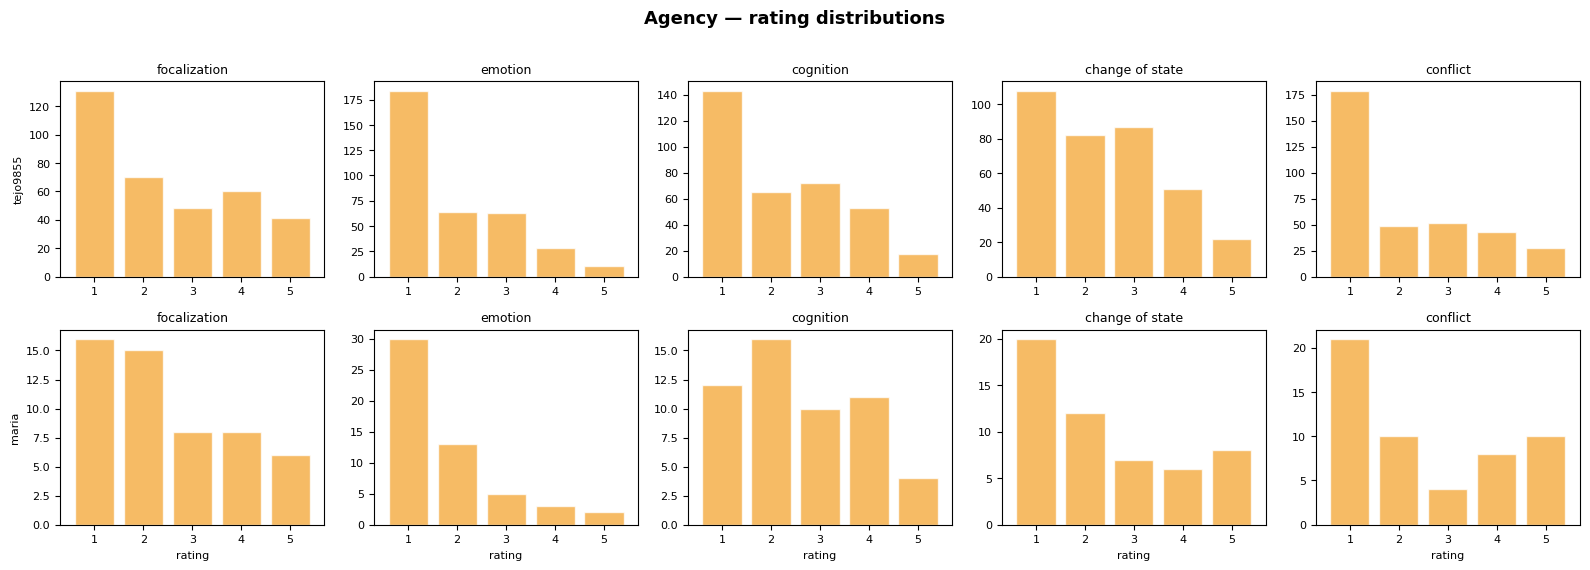

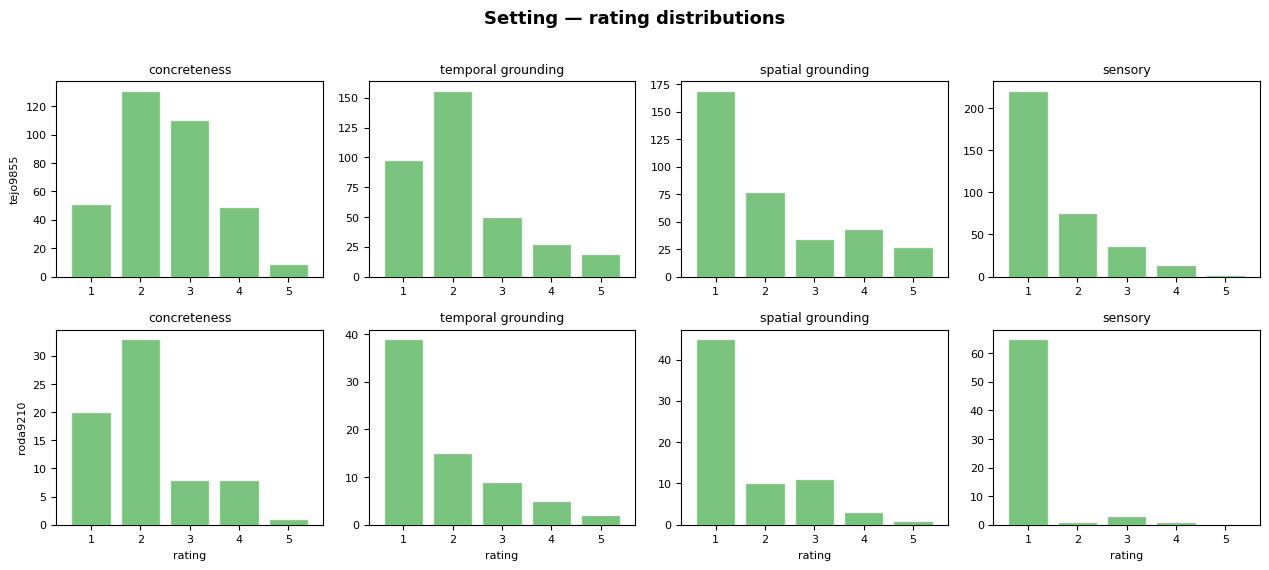

In [47]:
import matplotlib.pyplot as plt

TASK_PLOT_COLOR = {
    'agency':  '#f4a432',
    'setting': '#4caf50',
}

for task_key, cfg in TASKS.items():
    if cfg['format'] != 'likert':
        continue
    dims = cfg['dimensions']
    annotators = [a for a in cfg['annotators'] if all_data[task_key].get(a)]
    if not annotators:
        continue

    n_dims = len(dims)
    n_anns = len(annotators)
    fig, axes = plt.subplots(n_anns, n_dims, figsize=(3.2 * n_dims, 2.8 * n_anns),
                             sharey=False, squeeze=False)
    fig.suptitle(f'{cfg["label"]} — rating distributions', fontsize=13, fontweight='bold', y=1.01)

    color = TASK_PLOT_COLOR[task_key]
    for ai, ann in enumerate(annotators):
        ann_data = all_data[task_key][ann]
        for di, dim in enumerate(dims):
            ax = axes[ai][di]
            vals = [
                ann_data[inst].get(dim)
                for inst in ann_data
                if ann_data[inst] is not None and ann_data[inst].get(dim) is not None
            ]
            counts = [vals.count(v) for v in range(1, 6)]
            ax.bar(range(1, 6), counts, color=color, alpha=0.75, edgecolor='white')
            ax.set_xticks(range(1, 6))
            ax.set_xlim(0.3, 5.7)
            short = dim.split('_', 1)[1].replace('_', ' ') if '_' in dim else dim
            ax.set_title(short, fontsize=9)
            if di == 0:
                ax.set_ylabel(ann, fontsize=8)
            if ai == n_anns - 1:
                ax.set_xlabel('rating', fontsize=8)
            ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.show()

## Event Relation — Per-Instance Detail

In [38]:
SPAN1_COLOR = '#4e9af1'
SPAN2_COLOR = '#f4a432'

def ev(ann, key): return 'Y' if ann.get(key) else 'N'

er_anns = [a for a in TASKS['event_relation']['annotators'] if all_data['event_relation'].get(a)]

for ANN1, ANN2 in combinations(er_anns, 2):
    er1 = all_data['event_relation'][ANN1]
    er2 = all_data['event_relation'][ANN2]
    shared_er = set(er1) & set(er2)

    detail_rows = []
    for inst_id in dataset_order:
        if inst_id not in shared_er: continue
        a1, a2 = er1.get(inst_id), er2.get(inst_id)
        if a1 is None or a2 is None: continue

        sp1_agree = bool(a1.get('span1_is_event')) == bool(a2.get('span1_is_event'))
        sp2_agree = bool(a1.get('span2_is_event')) == bool(a2.get('span2_is_event'))
        t1, t2 = a1.get('temporal_order'), a2.get('temporal_order')
        c1, c2 = a1.get('causality_rating'), a2.get('causality_rating')
        temp_str = f'{t1} / {t2}' if t1 is not None and t2 is not None else '-'
        caus_str = f'{c1} / {c2}' if c1 is not None and c2 is not None else '-'
        temp_agree = t1 == t2 if t1 is not None and t2 is not None else None
        caus_agree = c1 == c2 if c1 is not None and c2 is not None else None

        green = 'background:#d4edda'
        detail_rows.append(
            f'<tr style="border-top:1px solid #eee">'
            f'<td style="padding:4px 10px;font-size:0.8em;color:#888">{inst_id}</td>'
            f'<td style="padding:4px 10px;text-align:center;{green if sp1_agree else ""}">'
                f'{ev(a1,"span1_is_event")} / {ev(a2,"span1_is_event")}</td>'
            f'<td style="padding:4px 10px;text-align:center;{green if sp2_agree else ""}">'
                f'{ev(a1,"span2_is_event")} / {ev(a2,"span2_is_event")}</td>'
            f'<td style="padding:4px 10px;text-align:center;{green if temp_agree else ""}">{temp_str}</td>'
            f'<td style="padding:4px 10px;text-align:center;{green if caus_agree else ""}">{caus_str}</td>'
            f'</tr>'
        )

    detail_header = (
        '<tr style="background:#f0f0f0">'
        '<th style="padding:4px 10px;text-align:left">Instance</th>'
        f'<th style="padding:4px 10px;color:{SPAN1_COLOR}">Span 1 event ({ANN1} / {ANN2})</th>'
        f'<th style="padding:4px 10px;color:{SPAN2_COLOR}">Span 2 event ({ANN1} / {ANN2})</th>'
        '<th style="padding:4px 10px">Temporal order</th>'
        '<th style="padding:4px 10px">Causality</th>'
        '</tr>'
    )

    display(HTML(
        f'<div style="font-family:sans-serif;margin-bottom:20px">'
        f'<b>{ANN1}</b> vs <b>{ANN2}</b> — {len(detail_rows)} shared instances'
        f'<table style="border-collapse:collapse;font-size:0.9em;margin-top:8px">'
        f'<thead>{detail_header}</thead>'
        f'<tbody>{"".join(detail_rows)}</tbody>'
        '</table></div>'
    ))

Instance,Span 1 event (tejo9855 / maria),Span 2 event (tejo9855 / maria),Temporal order,Causality
inst_8a19f018aeb5cd85_0,N / N,N / N,-,-
inst_07674afaf6952f79_1,Y / Y,Y / Y,span1_first / span1_first,enables / enables
inst_bb2995f1272965ff_2,Y / Y,Y / Y,span1_first / span1_first,not_related / not_related
inst_bc6923d20a046654_3,Y / Y,Y / Y,span1_first / span1_first,direct_cause / direct_cause
inst_f2bc022b2bcb0668_4,Y / Y,Y / Y,span1_first / span1_first,enables / enables
inst_33c156d5be8355a3_6,N / N,Y / Y,-,-
inst_eb818f83d1e944c6_7,Y / Y,Y / Y,span1_first / span1_first,enables / enables
inst_0f887acfa9e00da7_8,Y / Y,Y / Y,span1_first / span1_first,enables / enables
inst_c6c4d485162e761d_9,N / N,N / N,-,-
inst_2f5f05c0a25d1ca5_10,Y / Y,Y / Y,simultaneous / simultaneous,not_related / direct_cause


## Event Relation — Confusion Matrices (tejo9855 vs maria)

Rows = tejo9855 (gold), Columns = maria (predicted). Only shared instances where both annotators provided a value are included.

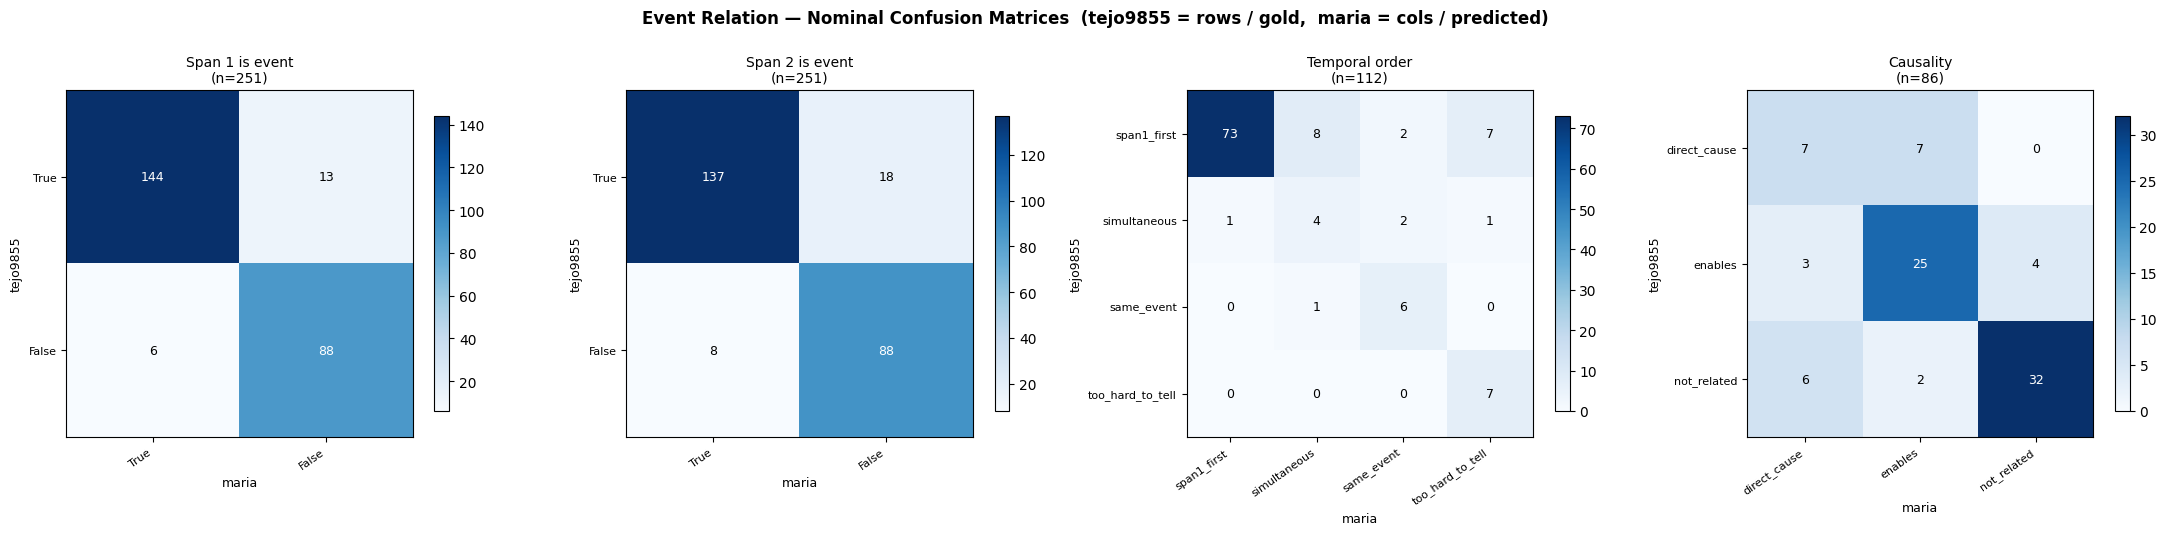

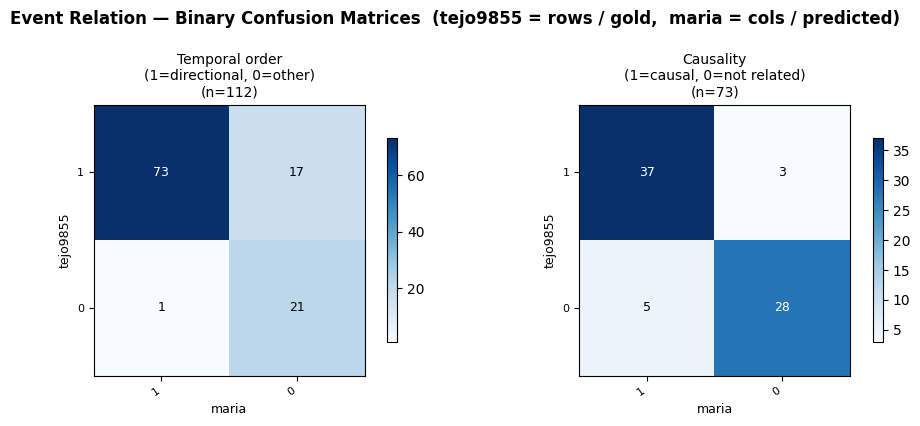

In [39]:
import matplotlib.pyplot as plt
import numpy as np

ANN_GOLD = 'tejo9855'
ANN_PRED = 'maria'

er_gold = all_data['event_relation'].get(ANN_GOLD, {})
er_pred = all_data['event_relation'].get(ANN_PRED, {})
shared  = set(er_gold) & set(er_pred)

def confusion_matrix_data(gold_vals, pred_vals, labels):
    idx = {l: i for i, l in enumerate(labels)}
    n   = len(labels)
    mat = np.zeros((n, n), dtype=int)
    for g, p in zip(gold_vals, pred_vals):
        if g in idx and p in idx:
            mat[idx[g]][idx[p]] += 1
    return mat

def plot_cm(ax, mat, labels, title, n_pairs):
    n = len(labels)
    im = ax.imshow(mat, cmap='Blues')
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    tick_labels = [str(l) for l in labels]
    ax.set_xticklabels(tick_labels, rotation=35, ha='right', fontsize=8)
    ax.set_yticklabels(tick_labels, fontsize=8)
    ax.set_xlabel(ANN_PRED, fontsize=9)
    ax.set_ylabel(ANN_GOLD, fontsize=9)
    ax.set_title(f'{title}\n(n={n_pairs})', fontsize=10)
    thresh = mat.max() / 2
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(mat[i, j]), ha='center', va='center', fontsize=9,
                    color='white' if mat[i, j] > thresh else 'black')
    plt.colorbar(im, ax=ax, shrink=0.75)

# ── Nominal matrices ──────────────────────────────────────────────────────────
nominal_dims = [
    ('Span 1 is event',  'span1_is_event',   [True, False],                               lambda v: bool(v)),
    ('Span 2 is event',  'span2_is_event',   [True, False],                               lambda v: bool(v)),
    ('Temporal order',   'temporal_order',   ['span1_first', 'span2_first',
                                              'simultaneous', 'same_event',
                                              'too_hard_to_tell'],                        lambda v: v),
    ('Causality',        'causality_rating', ['direct_cause', 'enables', 'not_related'],  lambda v: v),
]

fig1, axes1 = plt.subplots(1, 4, figsize=(22, 5))
fig1.suptitle(f'Event Relation — Nominal Confusion Matrices'
              f'  ({ANN_GOLD} = rows / gold,  {ANN_PRED} = cols / predicted)',
              fontsize=12, fontweight='bold', y=1.02)

for ax, (title, key, raw_labels, transform) in zip(axes1, nominal_dims):
    gold_vals, pred_vals = [], []
    for inst_id in dataset_order:
        if inst_id not in shared: continue
        g = er_gold.get(inst_id)
        p = er_pred.get(inst_id)
        if g is None or p is None: continue
        gv = transform(g.get(key)) if g.get(key) is not None else None
        pv = transform(p.get(key)) if p.get(key) is not None else None
        if gv is not None and pv is not None:
            gold_vals.append(gv)
            pred_vals.append(pv)
    present = set(gold_vals) | set(pred_vals)
    labels  = [l for l in raw_labels if l in present]
    mat     = confusion_matrix_data(gold_vals, pred_vals, labels)
    plot_cm(ax, mat, labels, title, len(gold_vals))

plt.tight_layout()
plt.show()

# ── Binary matrices ───────────────────────────────────────────────────────────
# Collect temporal and causality values for binary versions (excluding simultaneous)
temp_gold, temp_pred = [], []
caus_gold, caus_pred = [], []

for inst_id in dataset_order:
    if inst_id not in shared: continue
    g = er_gold.get(inst_id)
    p = er_pred.get(inst_id)
    if g is None or p is None: continue
    if not (g.get('span1_is_event') and g.get('span2_is_event') and
            p.get('span1_is_event') and p.get('span2_is_event')):
        continue
    t1, t2 = g.get('temporal_order'), p.get('temporal_order')
    c1, c2 = g.get('causality_rating'), p.get('causality_rating')
    if t1 is not None and t2 is not None:
        temp_gold.append(int(t1 in ('span1_first', 'span2_first')))
        temp_pred.append(int(t2 in ('span1_first', 'span2_first')))
    if c1 is not None and c2 is not None and t1 != 'simultaneous' and t2 != 'simultaneous':
        caus_gold.append(int(c1 != 'not_related'))
        caus_pred.append(int(c2 != 'not_related'))

binary_labels = [1, 0]
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4))
fig2.suptitle(f'Event Relation — Binary Confusion Matrices'
              f'  ({ANN_GOLD} = rows / gold,  {ANN_PRED} = cols / predicted)',
              fontsize=12, fontweight='bold', y=1.02)

plot_cm(axes2[0],
        confusion_matrix_data(temp_gold, temp_pred, binary_labels),
        binary_labels, 'Temporal order\n(1=directional, 0=other)', len(temp_gold))

plot_cm(axes2[1],
        confusion_matrix_data(caus_gold, caus_pred, binary_labels),
        binary_labels, 'Causality\n(1=causal, 0=not related)', len(caus_gold))

plt.tight_layout()
plt.show()

## Annotation Drift

Label value drift over annotation order — shows whether ratings shift as the annotator progresses through the queue. Configure `DRIFT_TASK`, `DRIFT_ANNOTATOR`, and `DRIFT_BIN_SIZE` to explore any annotator and task. Supports `'setting'` and `'agency'`.

In [ ]:
# ── Configuration ─────────────────────────────────────────────────────────────
DRIFT_TASK      = 'agency'    # 'setting' or 'agency'
DRIFT_ANNOTATOR = 'tejo9855'
DRIFT_BIN_SIZE  = 10          # instances per bin

# ── Load annotation sequence ──────────────────────────────────────────────────
import matplotlib.pyplot as plt

cfg = TASKS[DRIFT_TASK]
assert cfg['format'] == 'likert', "Drift analysis supports 'setting' and 'agency' only."

# annotation_order_<annotator> records the position in the queue at which this
# annotator saw each instance (exported from potato's instance_id_ordering).
dims      = cfg['dimensions']
order_col = f'annotation_order_{DRIFT_ANNOTATOR}'
label_cols = [f'{d}_{DRIFT_ANNOTATOR}' for d in dims]

df = load(DRIFT_TASK)
seq_df = (df[[order_col] + label_cols]
          .dropna(subset=[order_col])
          .rename(columns={order_col: 'annotation_order'})
          .rename(columns={f'{d}_{DRIFT_ANNOTATOR}': d for d in dims})
          .sort_values('annotation_order')
          .reset_index(drop=True))

prefix = DRIFT_TASK + '_'
short  = {d: d.replace(prefix, '').replace('_', ' ').title() for d in dims}
scale_min, scale_max = 1, 5   # all nine Likert dimensions are 1-5

# ── Bin and plot ───────────────────────────────────────────────────────────────
seq_df['bin'] = (seq_df['annotation_order'] - 1) // DRIFT_BIN_SIZE
bin_means   = seq_df.groupby('bin')[dims].mean()
bin_centers = bin_means.index * DRIFT_BIN_SIZE + (DRIFT_BIN_SIZE / 2)
bin_counts  = seq_df.groupby('bin').size()

fig, ax = plt.subplots(figsize=(11, 5))
for i, dim in enumerate(dims):
    ax.plot(bin_centers, bin_means[dim], marker='o',
            label=short[dim], color=plt.cm.tab10.colors[i], linewidth=2)

ax.axhline((scale_min + scale_max) / 2, color='gray', linestyle='--',
           linewidth=0.8, alpha=0.5, label='scale midpoint')
ax.set_ylim(scale_min - 0.2, scale_max + 0.2)
ax.set_xlabel(f'Annotation order (center of {DRIFT_BIN_SIZE}-instance bin)')
ax.set_ylabel('Mean rating')
ax.set_title(
    f'Annotation drift — {cfg["label"]} / {DRIFT_ANNOTATOR}'
    f'  (bin size = {DRIFT_BIN_SIZE}, n = {len(seq_df)})'
)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
for bc, bn in zip(bin_centers, bin_counts):
    ax.text(bc, scale_min - 0.13, f'n={bn}', ha='center', va='top', fontsize=7, color='#888')

plt.tight_layout()
plt.show()
